# Descenso del gradiente — Matemática 4 (UNLP)

Buscamos el **mínimo de una función** sin resolver a mano $\nabla f = 0$: sólo evaluamos el
gradiente y damos pasos en la dirección contraria.

$$\mathbf{p} \leftarrow \mathbf{p} - \eta\,\nabla f(\mathbf{p})$$


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

---
## 1 · Una variable: el ejemplo del apunte

$$f(x) = \tfrac{1}{2}x^2 + \tfrac{3}{2}, \qquad f'(x) = x$$

Sabemos que el mínimo está en $x=0$ (derivamos e igualamos a cero). Vamos a **ignorar eso** y
llegar iterando, para ver el mecanismo.

Parámetros del apunte: $x_0 = 1.4$, $\eta = 0.4$, tolerancia $\varepsilon = 0.01$.

In [3]:
def descenso_1d(f, fp, x0, eta, tol=1e-2, max_iter=200, criterio="delta_f"):
    """Descenso del gradiente en 1 variable.

    criterio="delta_f" -> corta cuando |f(x_{k+1}) - f(x_k)| < tol   (el del apunte)
    criterio="grad"    -> corta cuando |f'(x_k)| < tol
    Devuelve un DataFrame con la historia completa.
    """
    x = np.float64(x0)
    hist = [{"k": 0, "x": float(x), "f(x)": float(f(x)),
             "|f'(x)|": float(abs(fp(x))), "|delta f|": np.nan}]

    for k in range(1, max_iter + 1):
        x_ant, f_ant = x, f(x)
        with np.errstate(over="ignore", invalid="ignore"):
            x  = x_ant - eta * fp(x_ant)     # <--
            fx = f(x)
        delta = abs(fx - f_ant)
        hist.append({"k": k, "x": float(x), "f(x)": float(fx),
                     "|f'(x)|": float(abs(fp(x))), "|delta f|": float(delta)})

        if not np.isfinite(x):
            print(f"  DIVERGIO: x se fue a infinito/NaN en el paso {k}")
            break
        if criterio == "delta_f" and delta < tol:
            break
        if criterio == "grad" and abs(fp(x)) < tol:
            break
    else:
        print(f"  Se agotaron las {max_iter} iteraciones sin cumplir el criterio.")

    return pd.DataFrame(hist)


f  = lambda x: 0.5 * x**2 + 1.5
fp = lambda x: x                             # f'(x) = x

tabla = descenso_1d(f, fp, x0=1.4, eta=0.4, tol=0.01)
print(tabla.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

 k        x     f(x)  |f'(x)|  |delta f|
 0 1.400000 2.480000 1.400000        NaN
 1 0.840000 1.852800 0.840000   0.627200
 2 0.504000 1.627008 0.504000   0.225792
 3 0.302400 1.545723 0.302400   0.081285
 4 0.181440 1.516460 0.181440   0.029263
 5 0.108864 1.505926 0.108864   0.010535
 6 0.065318 1.502133 0.065318   0.003792


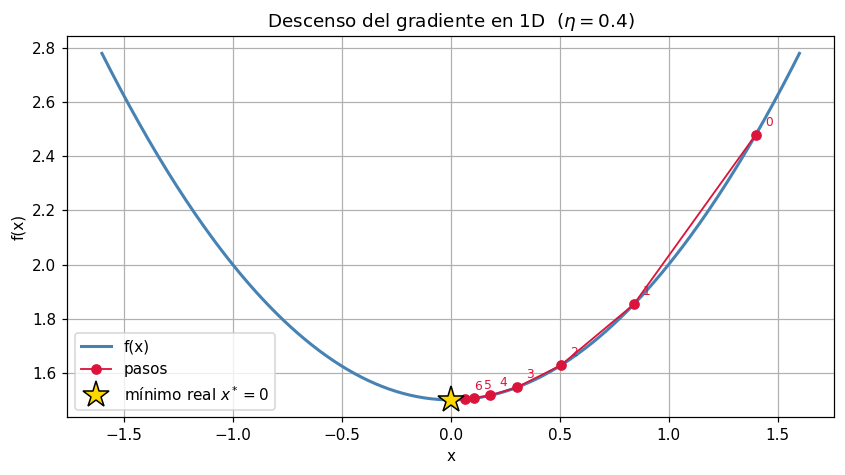

In [6]:
# Los pasos sobre la curva
xs = np.linspace(-1.6, 1.6, 300)

fig, ax = plt.subplots()
ax.plot(xs, f(xs), lw=2, color="steelblue", label=r"f(x)")
ax.plot(tabla["x"], tabla["f(x)"], "-o", color="crimson", ms=6, lw=1.2, label="pasos")

for _, r in tabla.iterrows():                # numerar los pasos
    ax.annotate(f"{int(r['k'])}", (r["x"], r["f(x)"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8, color="crimson")

ax.plot(0, f(0), "*", ms=18, color="gold", mec="k", zorder=5, label="mínimo real $x^*=0$")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title(r"Descenso del gradiente en 1D  ($\eta=0.4$)")
ax.legend()
plt.show()

---
## 2 · Ojo con el criterio de corte

El apunte corta cuando $|f(x_{k+1}) - f(x_k)| < \varepsilon$.

Si $\eta$ es chico, cada paso es diminuto $\Rightarrow$ $|\Delta f|$ es diminuto $\Rightarrow$ el
algoritmo para aunque estemos lejos. Comparemos los dos criterios.

In [7]:
filas = []
for eta in [0.01, 0.1, 0.4, 1.9]:
    a = descenso_1d(f, fp, 1.4, eta, tol=0.01, max_iter=5000, criterio="delta_f")
    b = descenso_1d(f, fp, 1.4, eta, tol=0.01, max_iter=5000, criterio="grad")
    filas.append({"eta": eta,
                  "pasos (|df|<0.01)": len(a) - 1, "x final": a["x"].iloc[-1],
                  "pasos (|f'|<0.01)": len(b) - 1, "x final ": b["x"].iloc[-1]})

print(pd.DataFrame(filas).to_string(index=False, float_format=lambda v: f"{v: .5f}"))
print()
print("Leer la fila eta=0.01: el criterio del apunte corta en x = 0.985.")
print("El minimo esta en x = 0. Freno a mitad de camino y dijo que habia llegado.")

     eta  pasos (|df|<0.01)  x final  pasos (|f'|<0.01)  x final 
 0.01000                 35  0.98483                492   0.00997
 0.10000                 15  0.28825                 47   0.00990
 0.40000                  6  0.06532                 10   0.00847
 1.90000                 15 -0.28825                 47  -0.00990

Leer la fila eta=0.01: el criterio del apunte corta en x = 0.985.
El minimo esta en x = 0. Freno a mitad de camino y dijo que habia llegado.


**Conclusión:** $|\Delta f| < \varepsilon$ es barato pero mentiroso con $\eta$ chico.
$\|\nabla f\| < \varepsilon$ mide la distancia al punto crítico. En la práctica se usan
los dos, más un tope de iteraciones.


---
## 3 · Dos variables: el cuenco

$$f(x,y) = x^2 + 2y^2, \qquad
\nabla f(x,y) = \begin{pmatrix} 2x \\ 4y \end{pmatrix}$$

Mismo algoritmo, sólo que ahora el "hacia dónde bajar" lo da el **vector gradiente**.

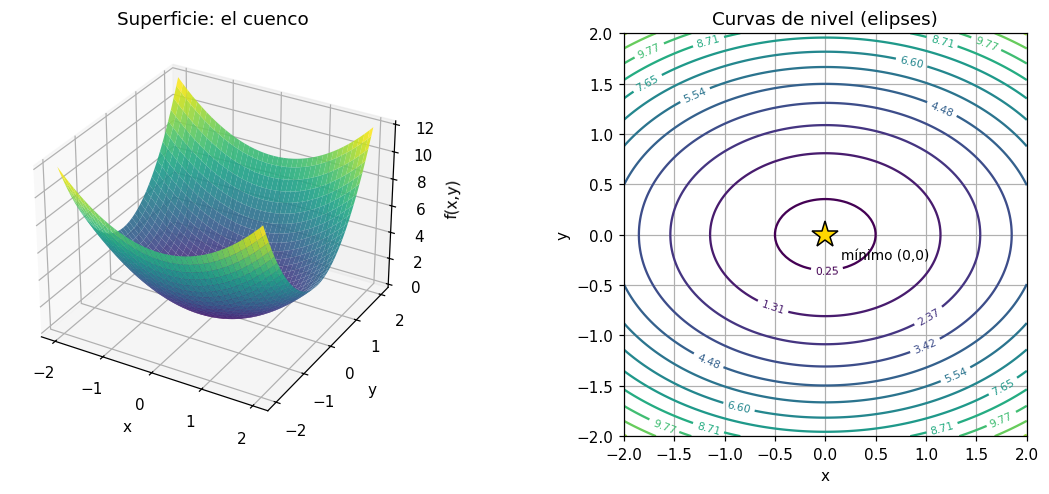

In [8]:
def fun(x, y):
    return x**2 + 2*y**2

def grad_fun(p):
    """Gradiente escrito a mano: (df/dx, df/dy)."""
    x, y = p
    return np.array([2*x, 4*y])

# grilla para graficar
r = 2.0
xg = np.linspace(-r, r, 120)
yg = np.linspace(-r, r, 120)
X, Y = np.meshgrid(xg, yg)
Z = fun(X, Y)

fig = plt.figure(figsize=(11, 4.6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.9, linewidth=0, antialiased=True)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f(x,y)")
ax1.set_title("Superficie: el cuenco")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(X, Y, Z, levels=np.linspace(0.25, 14, 14), cmap="viridis")
ax2.clabel(cs, inline=True, fontsize=7)
ax2.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5)
ax2.annotate("mínimo (0,0)", (0, 0), textcoords="offset points", xytext=(10, -16), fontsize=9)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_aspect("equal")
ax2.set_title("Curvas de nivel (elipses)")

plt.tight_layout(); plt.show()

In [9]:
def descenso_2d(grad, p0, eta, tol=1e-6, max_iter=200):
    """Descenso del gradiente en varias variables. Devuelve la trayectoria (n+1, 2)."""
    p = np.array(p0, dtype=np.float64)
    H = [p.copy()]
    for k in range(max_iter):
        with np.errstate(over="ignore", invalid="ignore"):
            p = p - eta * grad(p)            # <-- la misma regla, ahora vectorial
        H.append(p.copy())
        if not np.all(np.isfinite(p)):
            print(f"  DIVERGIO en el paso {k+1}")
            break
        if np.linalg.norm(grad(p)) < tol:
            break
    return np.array(H)


H = descenso_2d(grad_fun, p0=(-1.5, 1.5), eta=0.1)
print(f"pasos = {len(H)-1}   punto final = ({H[-1,0]: .3e}, {H[-1,1]: .3e})   f = {fun(*H[-1]):.3e}")

pasos = 67   punto final = (-4.821e-07,  2.052e-15)   f = 2.324e-13


---
## 4 · La trayectoria


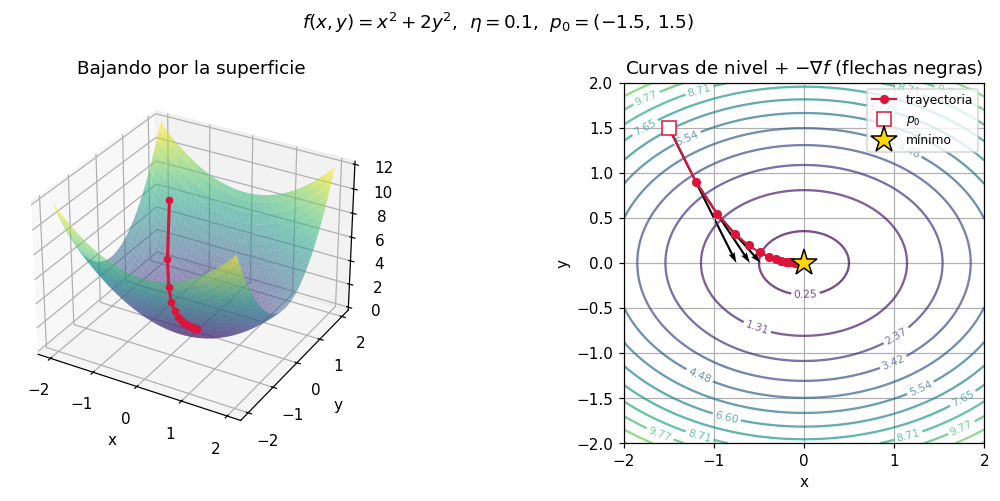

In [19]:
def dibujar_trayectoria(H, fun, grad, titulo="", r=2.0, flechas=3):
    xg = np.linspace(-r, r, 120); yg = np.linspace(-r, r, 120)
    X, Y = np.meshgrid(xg, yg); Z = fun(X, Y)

    fig = plt.figure(figsize=(11, 4.6))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.55, linewidth=0)
    Hv = H[np.all(np.isfinite(H), axis=1)]
    ax1.plot(Hv[:, 0], Hv[:, 1], fun(Hv[:, 0], Hv[:, 1]), "-o",
             color="crimson", ms=4, lw=2, zorder=10)
    ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_title("Bajando por la superficie")

    ax2 = fig.add_subplot(1, 2, 2)
    cs = ax2.contour(X, Y, Z, levels=np.linspace(0.25, 14, 14), cmap="viridis", alpha=0.7)
    ax2.clabel(cs, inline=True, fontsize=7)
    ax2.plot(Hv[:, 0], Hv[:, 1], "-o", color="crimson", ms=5, lw=1.4, label="trayectoria")

    for i in range(min(flechas, len(Hv) - 1)):     # dibujar -grad f en los primeros pasos
        g = grad(Hv[i])
        ax2.quiver(Hv[i, 0], Hv[i, 1], -g[0], -g[1], angles="xy",
                   scale_units="xy", scale=4, color="black", width=0.006)

    ax2.plot(Hv[0, 0], Hv[0, 1], "s", ms=9, color="white", mec="crimson", label="$p_0$")
    ax2.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5, label="mínimo")
    ax2.set_xlim(-r, r); ax2.set_ylim(-r, r); ax2.set_aspect("equal")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    ax2.set_title(r"Curvas de nivel + $-\nabla f$ (flechas negras)")
    ax2.legend(loc="upper right", fontsize=8)

    fig.suptitle(titulo)
    plt.tight_layout(); plt.show()


dibujar_trayectoria(H, fun, grad_fun, titulo=r"$f(x,y)=x^2+2y^2$,  $\eta=0.1$,  $p_0=(-1.5,\,1.5)$")

---
## 5 · El rol de $\eta$

Cuatro regímenes, todos con la misma función y el mismo punto inicial.

In [15]:
ETAS = {0.02: "muy chico: avanza, pero tarda una eternidad",
        0.10: "bien: baja derecho y converge",
        0.45: "grande: cruza el valle de lado a lado (oscila) y aun asi converge",
        0.55: "pasado de rosca: se aleja cada vez mas -> inf / NaN"}

p0 = np.array([-1.5, 1.5])
print(f"punto inicial: |p0| = {np.linalg.norm(p0):.3f}\n")

for eta, comentario in ETAS.items():
    Hh = descenso_2d(grad_fun, p0, eta, max_iter=60)
    n_fin = np.linalg.norm(Hh[-1])
    ok = "OK  " if n_fin < np.linalg.norm(p0) else "BOOM"
    print(f"[{ok}] eta={eta:<5} 60 pasos -> |p| = {n_fin:.3e}   {comentario}")


punto inicial: |p0| = 2.121

[OK  ] eta=0.02  60 pasos -> |p| = 1.299e-01   muy chico: avanza, pero tarda una eternidad
[OK  ] eta=0.1   60 pasos -> |p| = 2.299e-06   bien: baja derecho y converge
[OK  ] eta=0.45  60 pasos -> |p| = 2.299e-06   grande: cruza el valle de lado a lado (oscila) y aun asi converge
[BOOM] eta=0.55  60 pasos -> |p| = 8.452e+04   pasado de rosca: se aleja cada vez mas -> inf / NaN


In [16]:
from ipywidgets import interact, FloatSlider, IntSlider

def demo(eta=0.1, pasos=25, x0=-1.5, y0=1.5):
    Hh = descenso_2d(grad_fun, (x0, y0), eta, max_iter=int(pasos))
    finito = np.all(np.isfinite(Hh[-1]))
    estado = (f"converge, |p| = {np.linalg.norm(Hh[-1]):.2e}" if finito
              else "DIVERGIO (inf / NaN)")
    dibujar_trayectoria(np.clip(Hh, -1e3, 1e3), fun, grad_fun,
                        titulo=f"eta = {eta:.3f}   |   {estado}")

interact(demo,
          eta=FloatSlider(min=0.01, max=0.60, step=0.01, value=0.10,
                          description="eta", continuous_update=False),
          pasos=IntSlider(min=1, max=60, step=1, value=25,
                          description="pasos", continuous_update=False),
          x0=FloatSlider(min=-1.9, max=1.9, step=0.1, value=-1.5, description="x0"),
          y0=FloatSlider(min=-1.9, max=1.9, step=0.1, value=1.5, description="y0"))

interactive(children=(FloatSlider(value=0.1, continuous_update=False, description='eta', max=0.6, min=0.01, st…

<function __main__.demo(eta=0.1, pasos=25, x0=-1.5, y0=1.5)>

---
## 6 · ¿Importa desde dónde arranco?

En un cuenco (función convexa con un único mínimo), **no**: todos los caminos van al mismo fondo.
Cambia cuánto tardan, no adónde llegan. Eso deja de ser cierto apenas la función tiene varios
valles — ahí el punto inicial decide en qué mínimo local caés.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5))
xg = np.linspace(-2, 2, 120); yg = np.linspace(-2, 2, 120)
Xg, Yg = np.meshgrid(xg, yg)
cs = ax.contour(Xg, Yg, fun(Xg, Yg), levels=np.linspace(0.25, 14, 14), cmap="viridis", alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7)

for p0, col in [((-1.8, 1.8), "crimson"), ((1.7, 0.3), "royalblue"),
                ((0.2, -1.9), "darkorange"), ((-1.9, -0.9), "seagreen")]:
    Hh = descenso_2d(grad_fun, p0, eta=0.1, max_iter=40)
    ax.plot(Hh[:, 0], Hh[:, 1], "-o", ms=4, lw=1.3, color=col, label=f"$p_0$={p0}")

ax.plot(0, 0, "*", ms=20, color="gold", mec="k", zorder=5)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Cuatro puntos iniciales, un solo destino")
ax.legend(fontsize=8)
plt.show()

---
## 7 · Ojo con las escalas: el zigzag

$$f(x,y) = x^2 + 50y^2$$

Ahora las curvas de nivel son elipses **muy** alargadas: un cañón angosto y largo. El gradiente
apunta casi perpendicular al eje del valle, así que el método rebota de pared a pared y avanza
poquísimo hacia el mínimo.

signo de y en los primeros 8 pasos: [ 1 -1  1 -1  1 -1  1 -1]  <- alterna: esta rebotando
despues de 60 pasos, x = -0.1468 (arranco en -1.5: casi no avanzo)


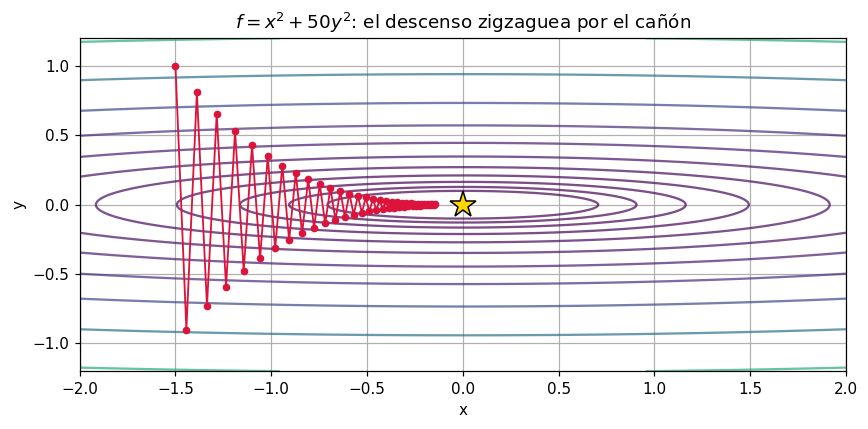

In [18]:
def fun_mal(x, y):
    return x**2 + 50*y**2

def grad_mal(p):
    x, y = p
    return np.array([2*x, 100*y])

H_mal = descenso_2d(grad_mal, p0=(-1.5, 1.0), eta=0.019, max_iter=60)
print("signo de y en los primeros 8 pasos:", np.sign(H_mal[:8, 1]).astype(int),
      " <- alterna: esta rebotando")
print(f"despues de {len(H_mal)-1} pasos, x = {H_mal[-1,0]:.4f} (arranco en -1.5: casi no avanzo)")

fig, ax = plt.subplots(figsize=(8, 4))
xg = np.linspace(-2, 2, 300); yg = np.linspace(-1.2, 1.2, 300)
Xg, Yg = np.meshgrid(xg, yg)
cs = ax.contour(Xg, Yg, fun_mal(Xg, Yg), levels=np.geomspace(0.5, 120, 12), cmap="viridis", alpha=.7)
ax.plot(H_mal[:, 0], H_mal[:, 1], "-o", color="crimson", ms=4, lw=1.2)
ax.plot(0, 0, "*", ms=18, color="gold", mec="k", zorder=5)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"$f=x^2+50y^2$: el descenso zigzaguea por el cañón")
plt.tight_layout(); plt.show()


## Las 3 ideas

1. **Para minimizar hay que ir contra el gradiente.** $\nabla f$ apunta a la subida; nosotros
   vamos al revés.
2. **Cada paso es: derivar, multiplicar por $\eta$, restar, repetir.** No resolvemos ninguna
   ecuación.
3. **$\eta$ es muy importante.** Chico $\to$ lento. Grande $\to$ oscila. Muy grande $\to$ explota. Y el umbral depende de la función.